<h1 style='text-align:center'>SUPERSTORE SALES PERFORMACE ANALYSIS</h1>

### Problem
 - Analyze sales performance across regions, categories, and products to identify key revenue drivers, uncover regional imbalances, and support data-driven business decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('SUPERSTORE SALES DATA.csv')
df.head()

,Row ID,Order ID,Order Date,Order Month,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,Aug,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,11/8/2017,Nov,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,6/12/2017,Jun,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,10/11/2016,Oct,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,10/11/2016,Oct,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.shape

(9800, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Order Month    9800 non-null   object 
 4   Ship Date      9800 non-null   object 
 5   Ship Mode      9800 non-null   object 
 6   Customer ID    9800 non-null   object 
 7   Customer Name  9800 non-null   object 
 8   Segment        9800 non-null   object 
 9   Country        9800 non-null   object 
 10  City           9800 non-null   object 
 11  State          9800 non-null   object 
 12  Postal Code    9789 non-null   float64
 13  Region         9800 non-null   object 
 14  Product ID     9800 non-null   object 
 15  Category       9800 non-null   object 
 16  Sub-Category   9800 non-null   object 
 17  Product Name   9800 non-null   object 
 18  Sales   

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Order Month       0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
clean_df = df.fillna('UNKNOWN')

In [8]:
clean_df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Order Month      0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### Sales by Region

In [9]:
clean_df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

,Region,Sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


### Best Category Sales Per Region

In [10]:
category_sales = clean_df.groupby(['Region', 'Category'], as_index=False)['Sales'].sum()

category_Sales_per_region = category_sales.sort_values('Sales',ascending=False).drop_duplicates('Region')
category_Sales_per_region

,Region,Category,Sales
5,East,Technology,263116.527
11,West,Technology,247404.930
2,Central,Technology,168739.208
8,South,Technology,148195.208


### Sales by Category

In [36]:
sales_by_Cat = clean_df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

Text(0, 0.5, 'Sales')

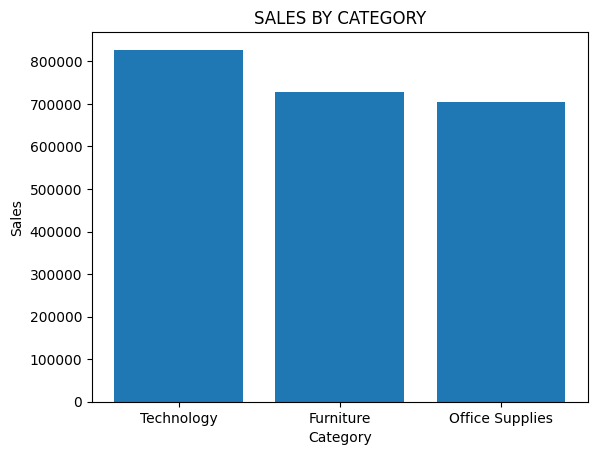

In [39]:
plt.bar(sales_by_Cat['Category'], sales_by_Cat['Sales'])
plt.title('SALES BY CATEGORY')

plt.xlabel('Category')
plt.ylabel('Sales')

### Top Products

In [12]:
per_product_total_sales = clean_df.groupby('Product Name', as_index=False)['Sales'].sum()

top_10_products = per_product_total_sales.sort_values('Sales',ascending=False).head(10)

top_10_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


### Top 10 Technology Products in West 

In [13]:
def top_10_tech_RegionProducts(Region):
    top_tech_products = clean_df[(clean_df['Category'] == 'Technology') & (clean_df['Region'] == Region)]
    top_10_tech_products = top_tech_products.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
    return top_10_tech_products
    
    

In [14]:
top_10_west = top_10_tech_RegionProducts('West')
top_10_west

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,13999.960
1,Okidata MB760 Printer,7834.400
2,Logitech P710e Mobile Speakerphone,7467.210
3,Hewlett Packard LaserJet 3310 Copier,6239.896
4,Zebra GX420t Direct Thermal/Thermal Transfer P...,5521.880
5,Samsung Galaxy Mega 6.3,5375.872
6,Apple iPhone 5,5198.640
7,Wilson Electronics DB Pro Signal Booster,4868.800
8,Cubify CubeX 3D Printer Double Head Print,4799.984
9,Logitech Z-906 Speaker sys - home theater - 5....,4289.870


In [15]:
top_10_east = top_10_tech_RegionProducts('East')
top_10_east

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,30099.914
1,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890
2,Hewlett Packard LaserJet 3310 Copier,8639.856
3,Apple iPhone 5,7797.960
4,Ativa V4110MDD Micro-Cut Shredder,7699.890
5,HP Designjet T520 Inkjet Large Format Printer ...,6999.960
6,Zebra ZM400 Thermal Label Printer,6965.700
7,Cubify CubeX 3D Printer Double Head Print,6299.979
8,Plantronics CS510 - Over-the-Head monaural Wir...,5081.230
9,Plantronics Savi W720 Multi-Device Wireless He...,4557.060


In [16]:
top_10_central = top_10_tech_RegionProducts('Central')
top_10_central

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,17499.950
1,Lexmark MX611dhe Monochrome Laser Printer,14279.916
2,Canon PC1060 Personal Laser Copier,4899.930
3,Mitel MiVoice 5330e IP Phone,4179.848
4,Polycom VVX 310 VoIP phone,3167.824
5,Samsung Galaxy S4,3004.752
6,Canon PC1080F Personal Copier,2999.950
7,Hewlett Packard 610 Color Digital Copier / Pri...,2999.940
8,Canon Imageclass D680 Copier / Fax,2799.960
9,Apple iPhone 5S,2735.952


In [17]:
top_10_south = top_10_tech_RegionProducts('South')
top_10_south

,Product Name,Sales
0,Cisco TelePresence System EX90 Videoconferenci...,22638.480
1,HP Designjet T520 Inkjet Large Format Printer ...,11374.935
2,Cubify CubeX 3D Printer Triple Head Print,7999.980
3,Samsung Galaxy Mega 6.3,7307.826
4,Samsung Galaxy S4 Active,3499.930
5,Cisco 9971 IP Video Phone Charcoal,3080.000
6,Hewlett-Packard Deskjet 3050a All-in-One Color...,3040.000
7,Hewlett Packard LaserJet 3310 Copier,2999.950
8,Samsung Galaxy S III - 16GB - pebble blue (T-M...,2939.916
9,Cisco SPA301,2839.018


#### Top 5 Common Technology Products Across Regions

In [18]:
all_regions = clean_df['Region'].unique()

all_Region_tops = pd.concat([top_10_tech_RegionProducts(r) for r in all_regions])

top_common_products = all_Region_tops['Product Name'].value_counts().sort_values(ascending=False).head(5).reset_index()

top_common_products

,Product Name,count
0,Hewlett Packard LaserJet 3310 Copier,3
1,Canon imageCLASS 2200 Advanced Copier,3
2,Samsung Galaxy Mega 6.3,2
3,HP Designjet T520 Inkjet Large Format Printer ...,2
4,Apple iPhone 5,2


### Total Sales of Common Products

In [19]:
top_common_products

,Product Name,count
0,Hewlett Packard LaserJet 3310 Copier,3
1,Canon imageCLASS 2200 Advanced Copier,3
2,Samsung Galaxy Mega 6.3,2
3,HP Designjet T520 Inkjet Large Format Printer ...,2
4,Apple iPhone 5,2


In [20]:
common_sales_df = clean_df[clean_df['Product Name'].isin(top_common_products['Product Name'])]

common_products_total_sales = common_sales_df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index()

common_products_total_sales

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Hewlett Packard LaserJet 3310 Copier,18839.686
2,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
3,Samsung Galaxy Mega 6.3,13943.668
4,Apple iPhone 5,12996.600


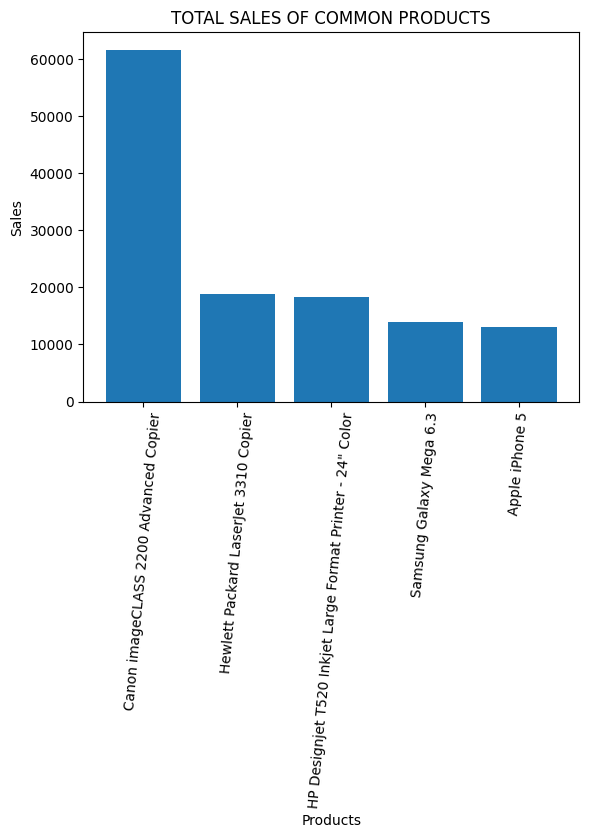

In [21]:
plt.bar(x=common_products_total_sales['Product Name'], height=common_products_total_sales['Sales'])
plt.title('TOTAL SALES OF COMMON PRODUCTS')
plt.xlabel('Products')
plt.ylabel('Sales')
plt.xticks(rotation=85)
plt.show()

### Are all top revenue products consistent across regions?

In [34]:
top_products_list = common_products_total_sales['Product Name']

top_products_df = clean_df[
    clean_df['Product Name'].isin(top_products_list)
]


In [35]:
top_products_df.groupby('Product Name')['Region'].nunique().sort_values(ascending=False).reset_index()

,Product Name,Region
0,Hewlett Packard LaserJet 3310 Copier,4
1,Samsung Galaxy Mega 6.3,3
2,Canon imageCLASS 2200 Advanced Copier,3
3,Apple iPhone 5,2
4,HP Designjet T520 Inkjet Large Format Printer ...,2


<H1 style='text-align:center'>KEY INSIGHTS</H1>

- The West region is the leading contributor to total sales, followed by the East region, indicating a regional imbalance in revenue distribution.
- The Technology category dominates sales across all regions, making it the primary driver of overall revenue.
- All top 10 highest-selling products belong to the Technology category, reinforcing its strong market demand.
- Certain products, such as Canon imageCLASS 2200 Advanced Copier and Hewlett Packard LaserJet 3310 Copier, consistently rank among top sellers across multiple regions  and also generate the highest total sales, indicating both strong demand and geographic stability.



<h1 style='text-align:center'>RECOMMENDATION</h1>

- Increase focus on underperforming regions (South and Central) by promoting high-performing technology products that have already proven successful in West and East regions.
- Prioritize inventory and marketing investment in consistently high-performing products, as they offer both strong revenue generation and lower regional risk.
- Implement targeted regional strategies for moderately consistent products, using localized promotions or discounts to expand their presence in weaker regions.
  